In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from AnalyzeDataset import AnalyzeDataset


## Table Of Contents:  
> Load the data  
> Initialize the Class: AD = AnalyzeDataset()    
> Call Fit: AD.fit_full_dataset_analysis(df) 
> Produce a DataFrame to View Fit Results: AD.column_relationships_df() 
> Plotting Options  
  

### Load data  

In [2]:
import Consumer_Habits_file_loader
from Consumer_Habits_file_loader import load_consumer_habits
df = pd.read_csv('../campaign_c_facebook_ads.csv')

In [11]:
df.head()


,xyz_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion,ClickThroughRate,ConversionRate,CostPerClick,CostPerConversion,Conversion_Value,ROAS,CostPerMille,RevenuePerMille,isFree,Free
0,campaign_c,3.0,2,10,1194718,141,254.049996,28,14,0.011802,0.500000,1.801773,18.146428,1400,5.510726,0.212644,1.171825,0,Paid
1,campaign_c,3.0,2,10,637648,67,122.400000,13,5,0.010507,0.384615,1.826866,24.480000,500,4.084967,0.191955,0.784132,0,Paid
2,campaign_c,3.0,2,10,24362,0,0.000000,1,1,0.000000,1.000000,0.000000,0.000000,100,0.000000,0.000000,4.104753,1,Free
3,campaign_c,3.0,2,10,459690,50,86.330001,5,2,0.010877,0.400000,1.726600,43.165001,200,2.316692,0.187800,0.435076,0,Paid
4,campaign_c,3.0,2,10,750060,86,161.909999,11,2,0.011466,0.181818,1.882674,80.955000,200,1.235254,0.215863,0.266645,0,Paid


# Initialize the Class with Default Parameters

In [3]:
# params: 
kruskal_assumption_check_params = {'levene_alpha':0.01,'ks_alpha':0.01,'return_pseudo':True, 'pseudo_test_max_global_ties_ratio': 0.7,
                                    'full_pseudo':False,'dropna':True, 'n_jobs':-8, 'guesstimate':{'rej_max_pct_in_group':0.2,
                                    'max_num_outlier_all_reject':3, 'max_pct_reject_total':0.2}}
anova_assumption_check_params   = {'normality_alpha':0.01, 'homogeneity_alpha':0.01, 'min_n':5, 'iqr_multiplier':2, 'dropna':True} 
chi2_assumption_check_params    = {'dropna':True}
supercat_subcat_params          = {'max_evidence':0.2,  'isolate_super_subs':False }
multivariate_params             = {'max_n_combination_size':2, 'max_n_combinations':50_000,  'min_combo_size':2}
multivariate_concatenation_delimiter = "_|&|_" 
numnum_meth_alpha_above_instructions = [('pearson',0.6,None),('spearman',0.6,None),('kendall',0.6,None)]
numcat_meth_alpha_above_instructions = [('kruskal',0.05,None),('anova',0.05,None)]
catcat_meth_alpha_above_instructions = [('chi2',0.05,None)] 
good_of_fit_uniform_test_instrucions = (0.05,None) 
normal_test_instructions             = (0.05,None) 


AD = AnalyzeDataset(multivariate_params = multivariate_params,
                        kruskal_assumption_check_params=kruskal_assumption_check_params,
                        anova_assumption_check_params = anova_assumption_check_params,
                        chi2_assumption_check_params = chi2_assumption_check_params,
                        supercat_subcat_params = supercat_subcat_params,
                        multivariate_concatenation_delimiter = multivariate_concatenation_delimiter,
                        numnum_meth_alpha_above_instructions=numnum_meth_alpha_above_instructions,
                        numcat_meth_alpha_above_instructions=numcat_meth_alpha_above_instructions,
                        catcat_meth_alpha_above_instructions=catcat_meth_alpha_above_instructions,
                        good_of_fit_uniform_test_instrucions=good_of_fit_uniform_test_instrucions,
                        normal_test_instructions=normal_test_instructions
                        )

              
                          
                          

# Fit statistically significant differences  
where fit_mulitvariates==True can have a big impact on compute time.  

In [4]:
AD.fit_full_dataset_analysis(df,  
                            numeric_columns=None,         # None for autodetect
                            categoric_columns=None,       # None for autodetect
                            numeric_target=None,          # None to compute all numeric varaibles as targets
                            categoric_target=None,        # None to compute all categoric varaibles as targets                          
                            fit_good_of_fit=True,         # instruct to test categoric variables for uniform distribution
                            fit_normal=True,
                            fit_multivariates=True,       # instruct to test multivariate significance
                            fit_supercat_subcats=True)    # test for supercategories with subcategories that partition other variables

/home/lelandmesford/Projects/Consumer_Habits/utils/Utils_HypTests_and_Coefficients/ANOVA.py:1268: RuntimeWarning: invalid value encountered in scalar divide
  MSB=SSB/dof_B
/home/lelandmesford/Projects/Consumer_Habits/utils/Utils_HypTests_and_Coefficients/ANOVA.py:1268: RuntimeWarning: invalid value encountered in scalar divide
  MSB=SSB/dof_B
/home/lelandmesford/Projects/Consumer_Habits/utils/Utils_HypTests_and_Coefficients/ANOVA.py:1268: RuntimeWarning: invalid value encountered in scalar divide
  MSB=SSB/dof_B
/home/lelandmesford/Projects/Consumer_Habits/utils/Utils_HypTests_and_Coefficients/ANOVA.py:1268: RuntimeWarning: invalid value encountered in scalar divide
  MSB=SSB/dof_B
/home/lelandmesford/Projects/Consumer_Habits/utils/Utils_HypTests_and_Coefficients/ANOVA.py:1268: RuntimeWarning: invalid value encountered in scalar divide
  MSB=SSB/dof_B
/home/lelandmesford/Projects/Consumer_Habits/utils/Utils_HypTests_and_Coefficients/ANOVA.py:1268: RuntimeWarning: invalid value encount

# A dataframe to summarize fit results based on rejected nulls and correlations above thresholds

In [5]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth',None)
display(AD.column_relationships_df(targets=None))

Where 'MaxLenComboComparedTo' can vary depending on compute limits and number of possible combinations in combo sizes.
'FeatureColum(s)' is a combination or single column that shares a significant relationship according to the test(s).
'Test(s)' lists the test(s) used. If the testname is followed by a colon, that signals whether assumptions were met for that specifit test.
xyz_campaign_id


FeatureColum(s)  \
Target              Type      Distribution          MaxLenCombosComparedTo                        
CostPerConversion   numeric   reject_normal         0                       Approved_Conversion   
                                                    0                          Conversion_Value   
                                                    0                                      Free   
Total_Conversion    numeric   reject_normal         0                               Impressions   
                                                    0                                    Clicks   
                                                    0                                     Spent   
                                                    0                       Approved_Conversion   
                                                    0                          Conversion_Value   
                                                    0                                      Free   
Free                categoric reject_uniform        0                                       age   
                                                    0                               Impressions   
                                                    0                                    Clicks   
                                                    0                                     Spent   
                                                    0                          Total_Conversion   
                                                    0                       Approved_Conversion   
                                                    0                          ClickThroughRate   
                                                    0                              CostPerClick   
                                                    0                         CostPerConversion   
                                                    0                          Conversion_Value   
                                                    0                                      ROAS   
                                                    0                              CostPerMille   
                                                    0                           xyz_campaign_id   
ConversionRate      numeric   reject_normal         0                           RevenuePerMille   
                                                    0                       Approved_Conversion   
                                                    0                          Conversion_Value   
                                                    0                                      ROAS   
ClickThroughRate    numeric   fail_to_reject_normal 0                              CostPerMille   
                                                    0                                      Free   
ROAS                numeric   reject_normal         0                           RevenuePerMille   
                                                    0                       Approved_Conversion   
                                                    0                            ConversionRate   
                                                    0                          Conversion_Value   
                                                    0                                      Free   
Spent               numeric   reject_normal         0                               Impressions   
                                                    0                                    Clicks   
                                                    0                          Total_Conversion   
                                                    0                                      Free   
Approved_Conversion numeric   reject_normal         0                               Impressions   
                                                    0                          Total_Conversion   
                     

# Low Level Details

### Access Results Globally for the Entire Dataset  

In [6]:
print('Categorical Columns that Rejected the Goodness-of-Fit Test for a Uniform Distribution'.upper())
print('          ',AD.reject_null_good_of_fit)
print('Categorical that Failed to Reject Uniform Distribution'.upper())
print('          ',AD.fail_to_reject_null_good_of_fit)
print('Numerical Columns that Rejected a test for Normal Distribution'.upper())
print('          ',AD.reject_null_normal)
print('Numerical that Failed to Reject a test for a Normal Distribution'.upper())
print('          ',AD.fail_to_reject_null_normal)
print('Numeric-Numeric Bivariates with Correlaiton Above the Threshold'.upper())
print('          ',AD.above_threshold_corr_numnum) 
print('Numeric-Numeric Bivariates with Correlaiton Below the Threshold'.upper())
print('          ',AD.below_threshold_corr_numnum)
print('Numeric-Categoric Bivariates that Rejected the Null Hypothesis'.upper())
print('          ',AD.reject_null_numcat)
print('Numeric-Categoric Bivariates that Failed to Reject the Null Hypothesis'.upper())
print('          ',AD.fail_to_reject_null_numcat)
print('Categoric-Categoric Bivariates that Rejected the Null Hypothesis'.upper())
print('          ',AD.reject_null_catcat)
print('Categoric-Categoric Bivariates that Failed to Reject the Null Hypothesis'.upper())
print('          ',AD.fail_to_reject_null_catcat)
print('Supercategory variables that partition another variable into Subcategories'.upper())
print('          ',AD.supercategory_subcategory_pairs)
print('Multivariat variables. Target and target type followed by a combination of categoric variables. Then the test type.'.upper())
print('          ',AD.significant_multivariate_combinations)
print('Univariate and Bivariate cases where test assumptions were not met.'.upper())
for k,v in AD.assumptions_not_met.items():
    print('          ',k,':  ',v)

CATEGORICAL COLUMNS THAT REJECTED THE GOODNESS-OF-FIT TEST FOR A UNIFORM DISTRIBUTION
           {'Free'}
CATEGORICAL THAT FAILED TO REJECT UNIFORM DISTRIBUTION
           set()
NUMERICAL COLUMNS THAT REJECTED A TEST FOR NORMAL DISTRIBUTION
           {'CostPerConversion', 'Total_Conversion', 'ConversionRate', 'gender', 'ROAS', 'interest', 'Spent', 'Approved_Conversion', 'age', 'Conversion_Value', 'Impressions', 'CostPerClick', 'RevenuePerMille', 'CostPerMille', 'Clicks', 'isFree'}
NUMERICAL THAT FAILED TO REJECT A TEST FOR A NORMAL DISTRIBUTION
           {'ClickThroughRate'}
NUMERIC-NUMERIC BIVARIATES WITH CORRELAITON ABOVE THE THRESHOLD
           [['Clicks', 'Impressions', 'kendall:nan-pearson:nan-spearman:nan'], ['Impressions', 'Spent', 'kendall:nan-pearson:nan-spearman:nan'], ['Impressions', 'Total_Conversion', 'pearson:nan-spearman:nan'], ['Approved_Conversion', 'Impressions', 'pearson:nan'], ['Conversion_Value', 'Impressions', 'pearson:nan'], ['Clicks', 'Spent', 'kendall:nan-pe

## ====================================================================================================   
# High Level Visuals   
## ====================================================================================================  

## Two Plot Functions W/ Dynamic Output

In [7]:
# parameters:
cat_univar_params =         {'proportions':False,'n_wide':(6,40,4),
                             'super_title':"Univariate Categorical Variables - Reject Good-Of-Fit for Uniform"}
catcat_bivar_params =       {'n_wide':(6,40,5),'stacked_bars_when_max_bars_is_exceeded':True,'sorted':False,
                             'super_title':"Categoric-To-Categoric Bivariates - Reject Null"}
numnum_bivar_params =       {'plot_type':'joint','linreg':True,'plot_type_kwargs':None,'linreg_kwargs':None,
                             'super_title':'Numeric Bivariates With Significant Correlation(s)'}
numcat_bivar_params =       {'plot_type':'boxen', 'n_wide':(6,40,8), 
                             'super_title':'Numeric-to-Categoric Bivariates  - Reject Null' }
super_subcat_pairs_params = {'row_height':2,'cols_per_row':3,'y_tick_fontsize':12,
                             'super_title':"Supercategory-Subcategory - One Categoric Variable Partitions Another"} 
num_univar_params =         {'kde':None,'proportions':False,'n_wide':(6,40,4),
                             'super_title':"Univariate Numerical Variables - Reject Normal Distribution",
                             'force_significant_bin_edges':None,  'minimize_significant_bins':None, 'include_multivariate':True} 



### Plot by input pairs, infer rejected null and correlation above threshold, or set to False   

Plot Categoric Univariate is set to False
Plot Numeric Univariate is set to False
Plot Bivariate Categoric-Categoric is set to False


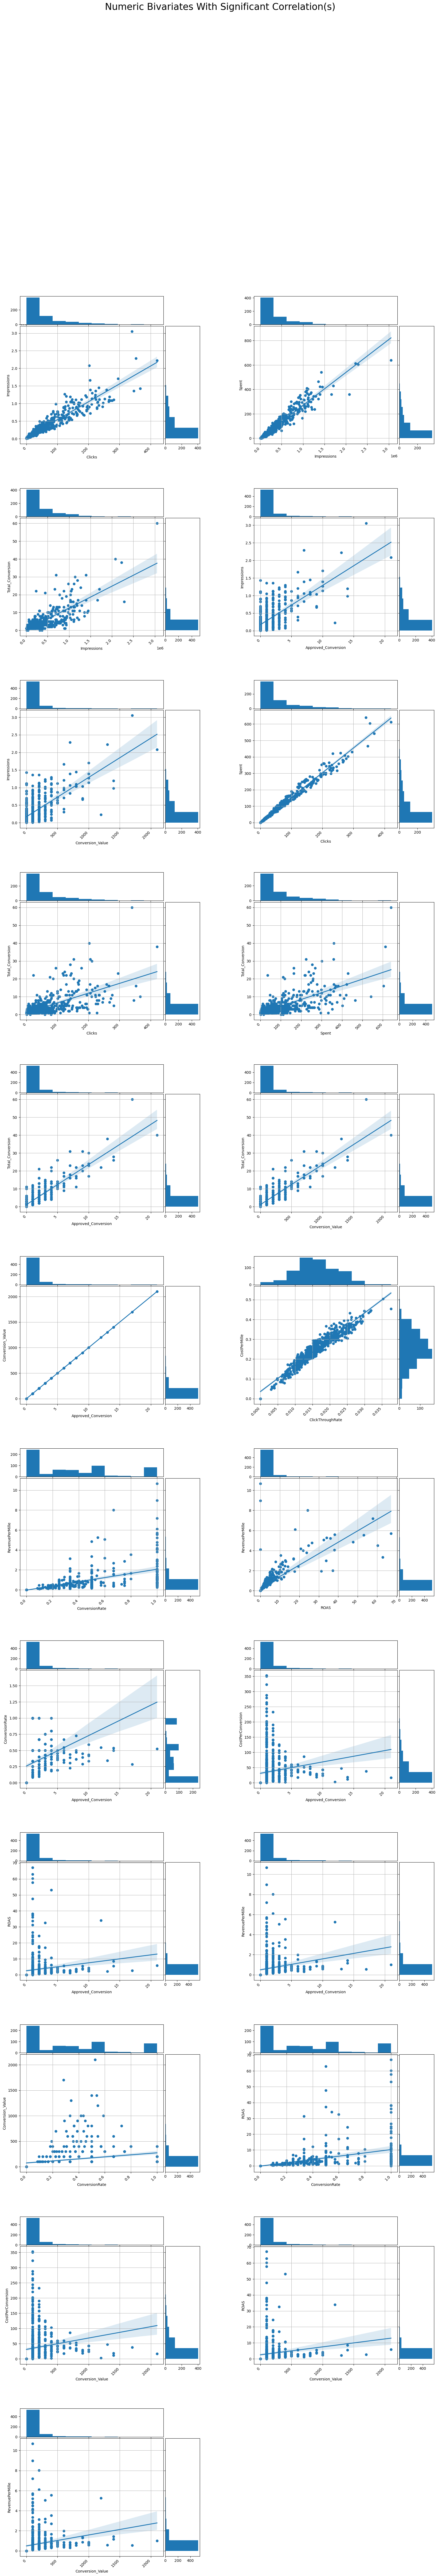

Plot Bivariate Numeric-Categoric is set to False
Plot Supercategory-Subcategory Partitions is set to False


In [8]:
# plots based on what has been fit globally
AD.produce_all_plots(df,
                    cat_univar=False,   # None or True indicate variables should be derived from fit results. Otherwise input list or str
                    num_univar=False, 
                    catcat_bivar=False,
                    numnum_bivar=True,
                    numcat_bivar=False,    # can manually input valus. such as: AD.assumptions_not_met['numcat']
                    super_subcat_pairs=False,
                    cat_univar_params = cat_univar_params,
                    catcat_bivar_params = catcat_bivar_params,
                    numnum_bivar_params = numnum_bivar_params,
                    numcat_bivar_params = {'super_title':"Assumptions Not Met"}, # numcat_bivar_params,
                    super_subcat_pairs_params = super_subcat_pairs_params,
                    num_univar_params = num_univar_params
                  )

### Plot individual targets based on reject null and correlation above threshold  
### Set how targets are output with the targets_share_plots perameter

In [9]:
# this one calls the other internally, but plots data based on per
AD.visualize_by_targets(
                        data=df,
                        targets='Illinois',      # targets are input here
                        reject_numcat=True,  # WHETHER TO PLOT OR NOT
                        reject_numnum=True,
                        reject_catcat=True,
                        is_super_or_subcat=True,
                        not_uniform_or_reject_normal=True,  
                        reject_multivariates=False,        # multivariate plots are not yet supported
                        auto_fit=True,   # to call fit function(s) when needed
                        targets_share_plots=False ,  # otherwise targets are plotted individually
                        check_assumptions=True,
                        dropna_gof=True,
                        cat_univar_params = cat_univar_params,
                        catcat_bivar_params = catcat_bivar_params,
                        numnum_bivar_params = numnum_bivar_params,
                        numcat_bivar_params = numcat_bivar_params,
                        super_subcat_pairs_params = super_subcat_pairs_params,
                        num_univar_params = num_univar_params
                        )

KeyError: 'Illinois'

## Histogram bin edges can be controlled such as to minimize number of bins while keeping statistical significant thresholds
## Or to exclude multivariate combinations

Pre examination of binning metrics for Total Days of Patronage show a per variable bin range of [2,556]:   
Plots vary based on using minimums, multivar, or max of min -vs- default

In [ ]:
mn,mp = AD.get_a_varaibles_binning_metrics(df,
                                        target='United States',
                                        check_multivar=True)
print('='*23)
print('coffee\US_FL_IL_2020_to_2025_Weekly_googtrendcoffeesearch.csv')
print('Absolute min bins: ', mn)
print('Bin meta: ',mp)
print('='*23)


United States
Absolute min bins:  3
Bin meta:  {'Florida': 2, 'Illinois': 2}


In [ ]:
pd.DataFrame({k:[v] for k,v in mp.items()})

,Florida,Illinois
0,2,2


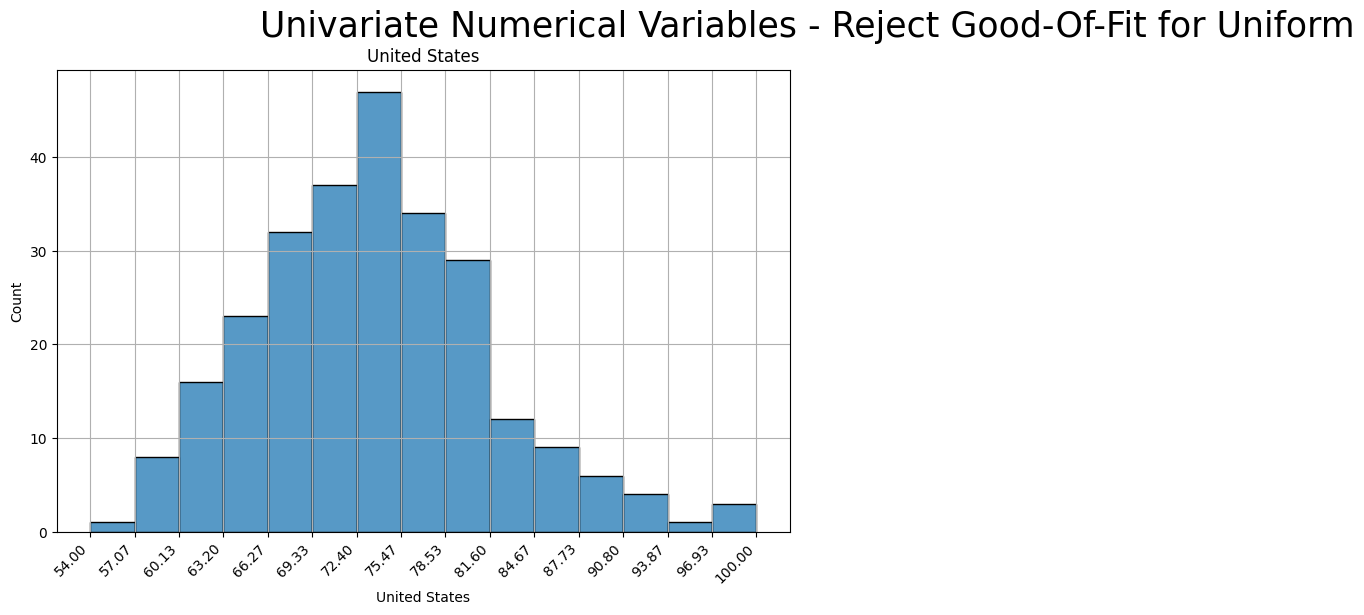

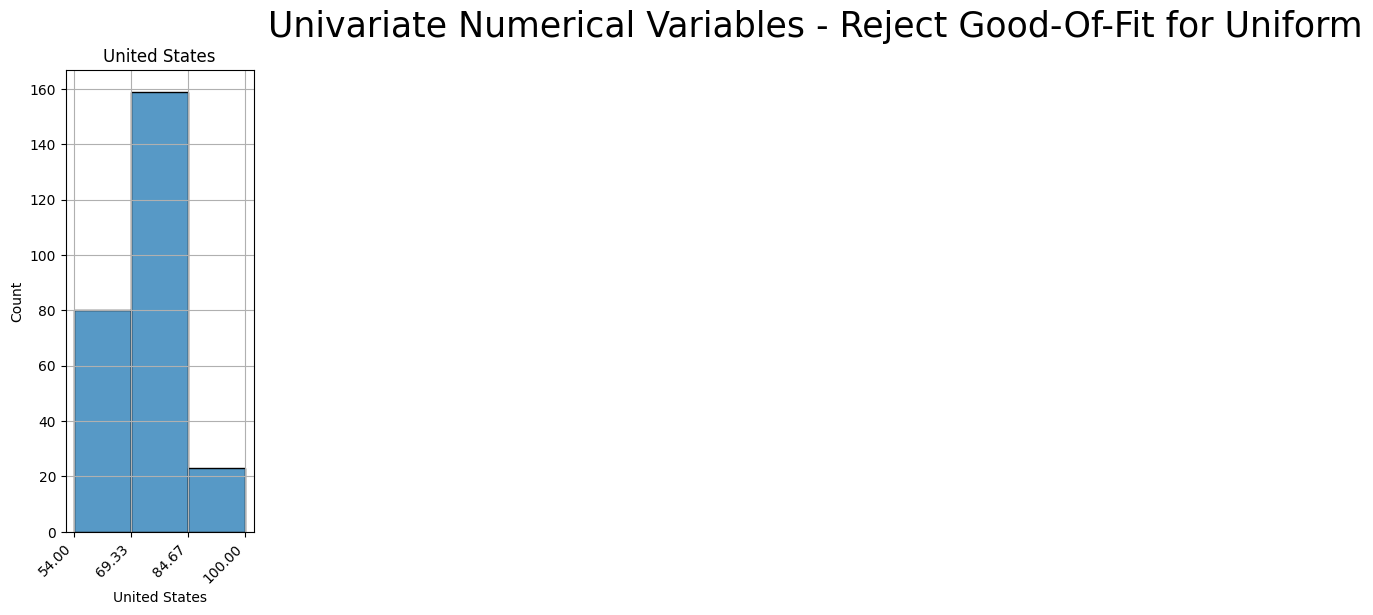

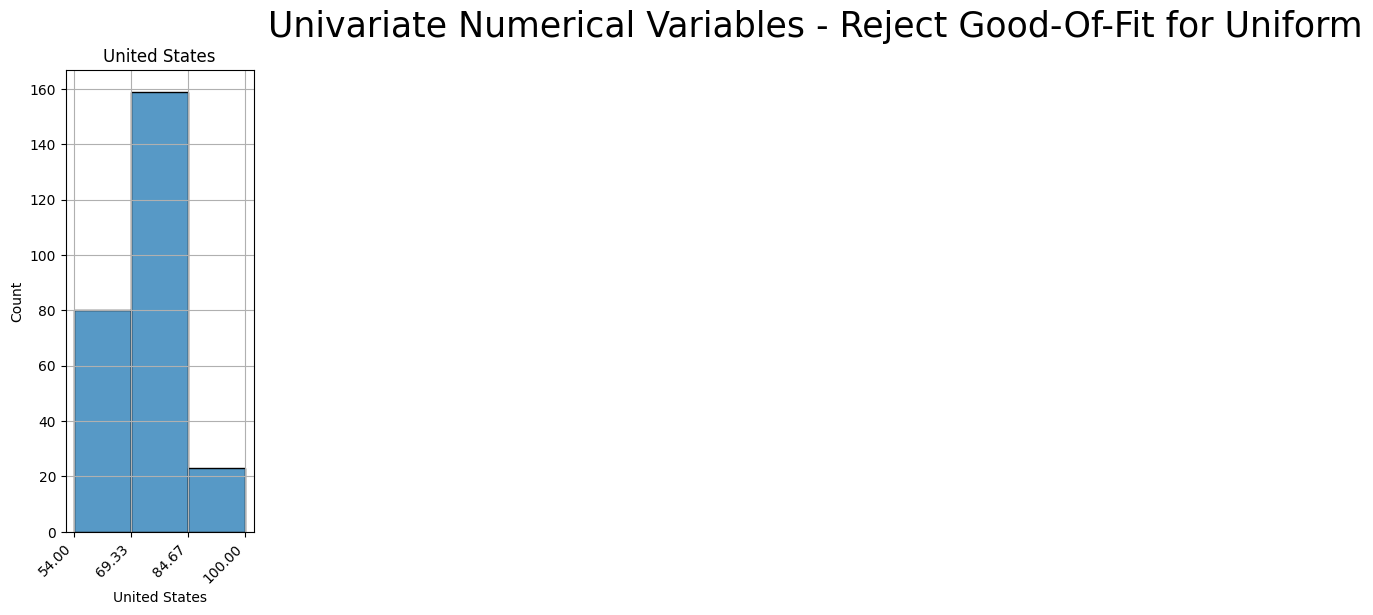

In [ ]:
AD.plot_non_normal_numeric(df,
                           numerical= ['United States'])
AD.plot_non_normal_numeric(df,
                           numerical= ['United States'],
                            force_significant_bin_edges=True,
                            minimize_significant_bins=True,
                            include_multivariate=True)
AD.plot_non_normal_numeric(df,
                           numerical= ['United States'],
                            force_significant_bin_edges=True,
                            minimize_significant_bins=True,
                            include_multivariate=False)

# Produce all significant plots in one shot

Plot Categoric Univariate is set to False


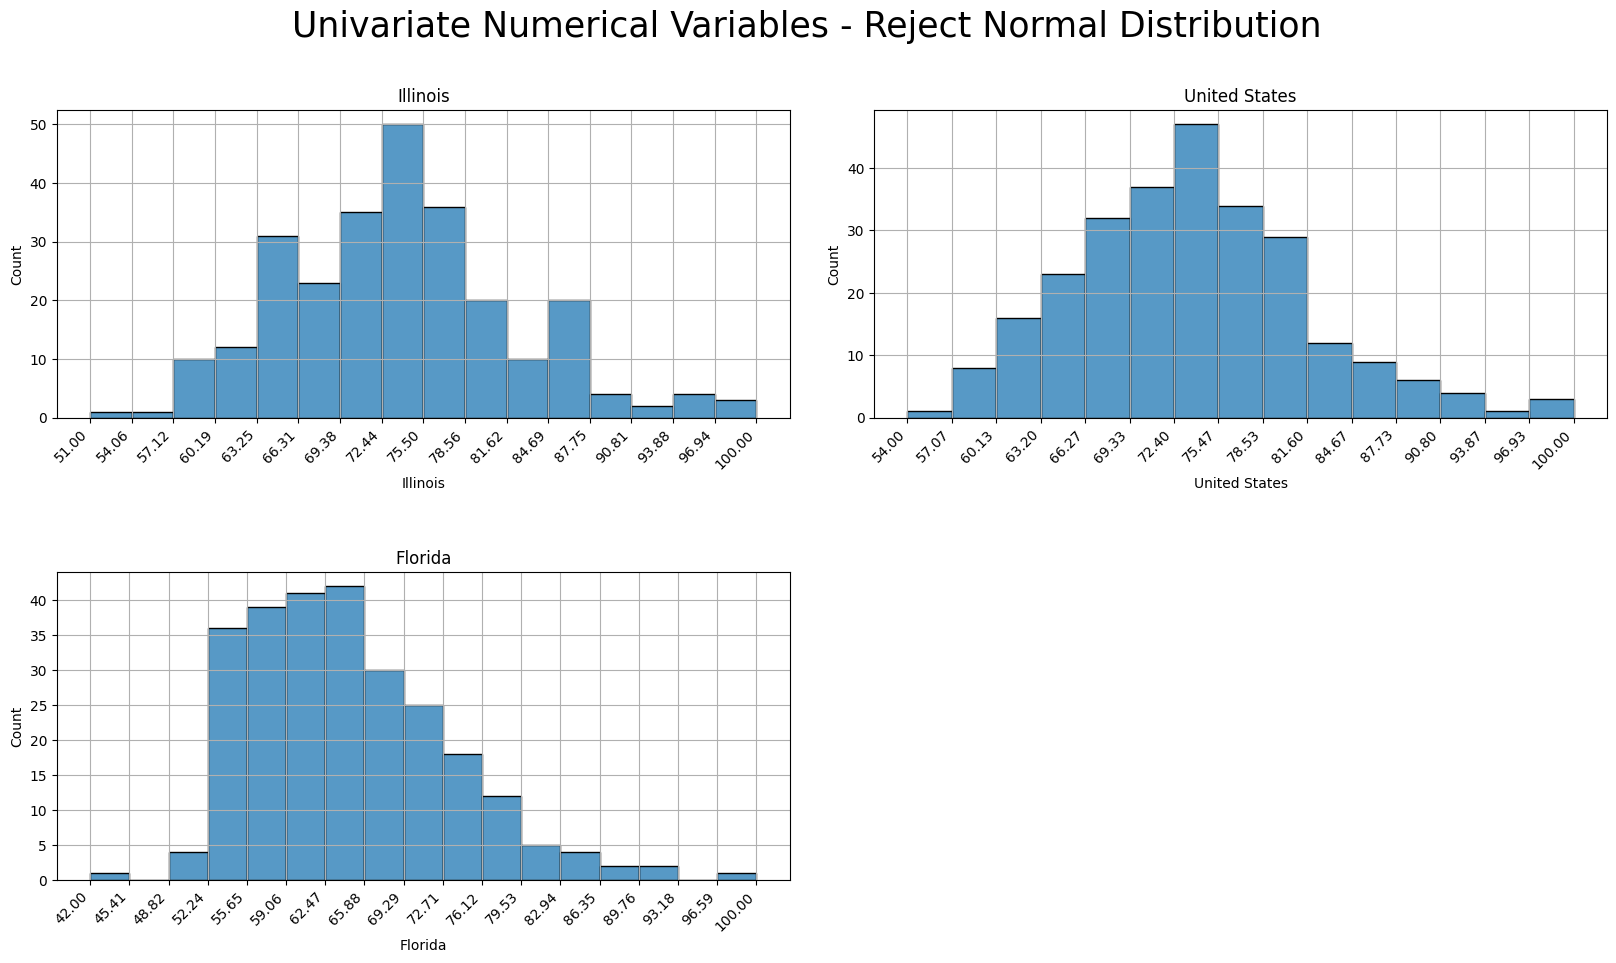

Plot Bivariate Categoric-Categoric is set to False


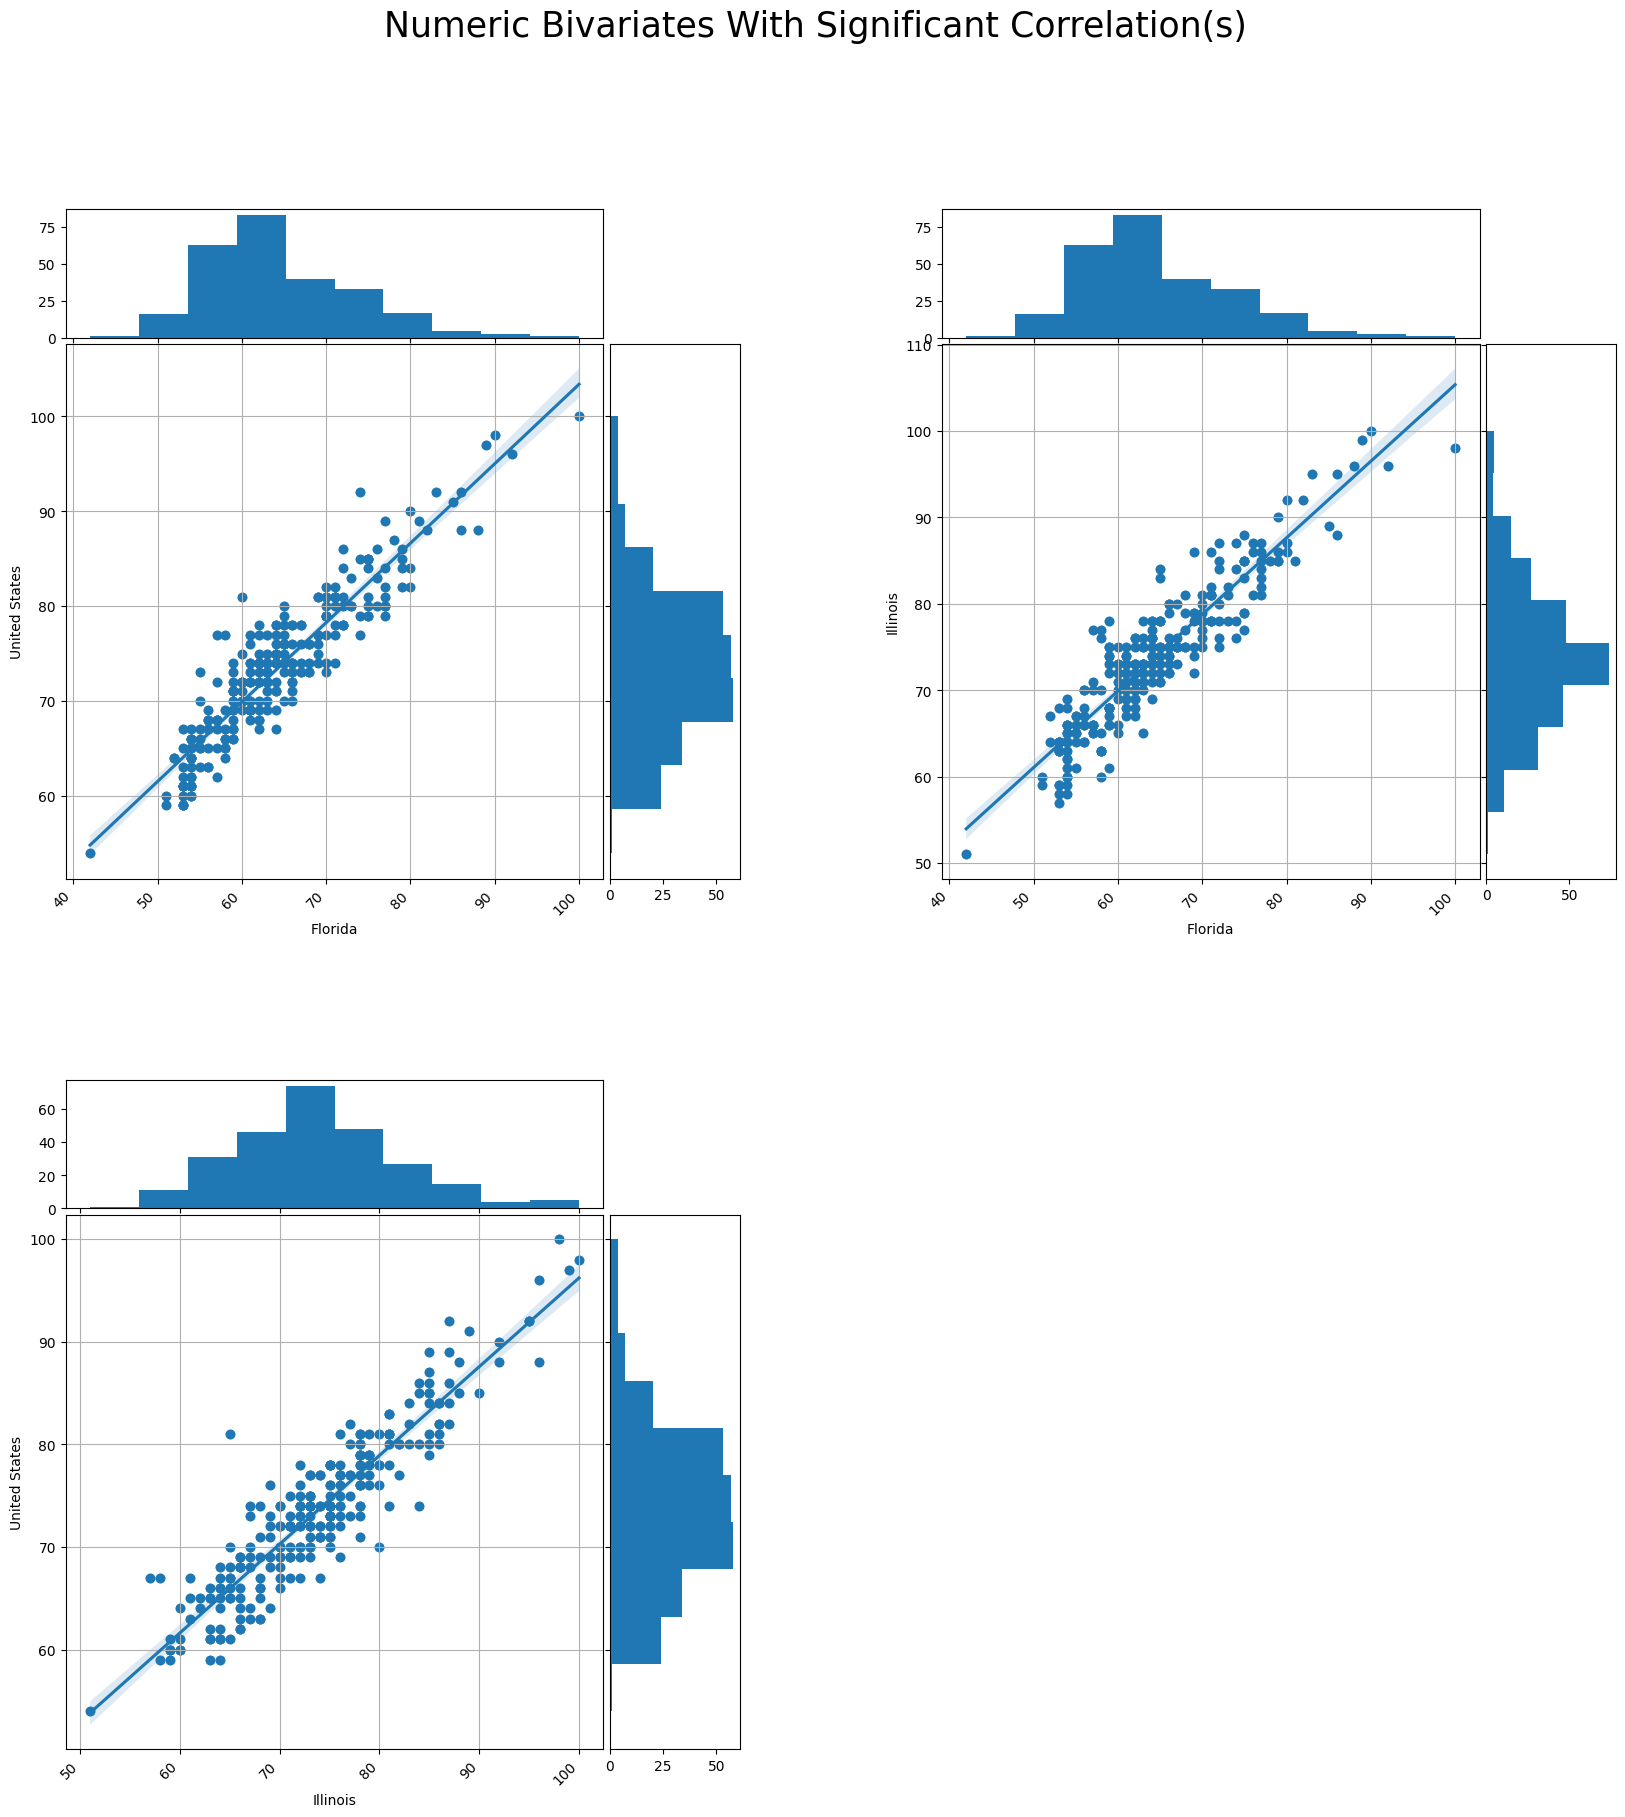

There are not any numeric-to-categoric column pairs with significant relationships.
Either none exist, or they haven't been fit.
There are not any Supercategory-Subcategory relationships to plot.
Either none exist, or they haven't been fit.


In [ ]:
AD.produce_all_plots(df,
                     cat_univar=False,
                     catcat_bivar=False,
                     )